<a href="https://colab.research.google.com/github/tyleresong/mis433/blob/main/assignment_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [56]:
import pandas as pd
import numpy as np

In [57]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [58]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [59]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [60]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()


,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [61]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb[imdb['Released_Year'] == 'PG']

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [62]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[966, 'Released_Year'] = '1995'
imdb.loc[966, 'Certificate'] = 'PG-13'
imdb.loc[966, :]

,966
Poster_Link,https://m.media-amazon.com/images/M/MV5BNjEzYj...
Series_Title,Apollo 13
Released_Year,1995
Certificate,PG-13
Runtime,140 min
Genre,"Adventure, Drama, History"
IMDB_Rating,7.6
Overview,NASA must devise a strategy to return Apollo 1...
Meta_score,77.0
Director,Ron Howard


In [63]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)

In [64]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
(
  imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
 .sort_values(by='Gross', ascending=False)
 [['Series_Title', 'Released_Year', 'Certificate', 'Gross']]
)

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [65]:
# Does the sorting result looks right to you? What's the problem?
# Gross is in string format

In [66]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
imdb['Gross'] = imdb['Gross'].str.replace(',', '')
imdb['Gross'] = imdb['Gross'].astype(float)

In [67]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
(
  imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
 .sort_values(by='Gross', ascending=False)
 [['Series_Title', 'Released_Year', 'Certificate', 'Gross']]
)

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [68]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
Runtime_min = imdb['Runtime'].str.replace(' min', '').astype(int)
imdb['Runtime_min'] = Runtime_min

In [69]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
Age_Year = 2026 - imdb['Released_Year']
imdb['Age_Year'] = Age_Year

In [70]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
Decade = (imdb['Released_Year'] // 10) * 10
imdb['Decade'] = Decade

## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

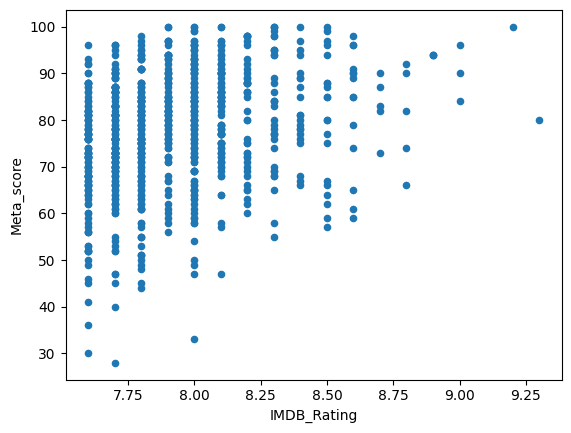

In [72]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
imdb.plot.scatter(x='IMDB_Rating', y='Meta_score')

# A majority of the movies have an IMDB rating between 7 and 8.25 while having a large variety of Meta scores.


<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

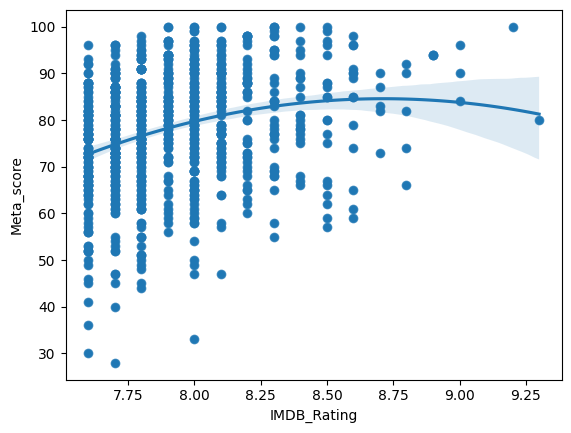

In [73]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
imdb.plot.scatter(x='IMDB_Rating', y='Meta_score')
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, order=2)

In [74]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
# The data point in the top right stands out as the only movie with a high IMDB rating and high Meta score.

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

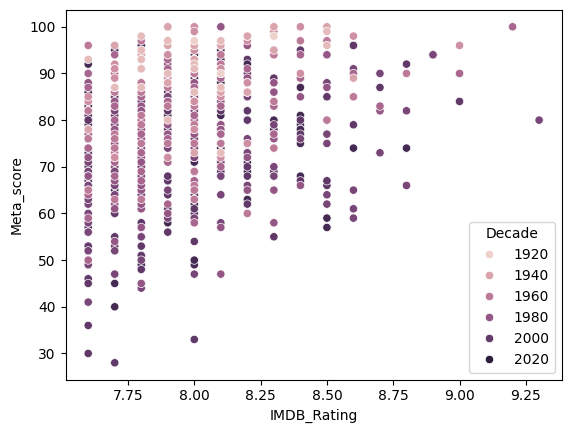

In [75]:
# In the scatterplot, use color to distinguish movies from different decades.
sns.scatterplot(data=imdb, x='IMDB_Rating', y='Meta_score', hue='Decade')

<Axes: xlabel='Decade'>

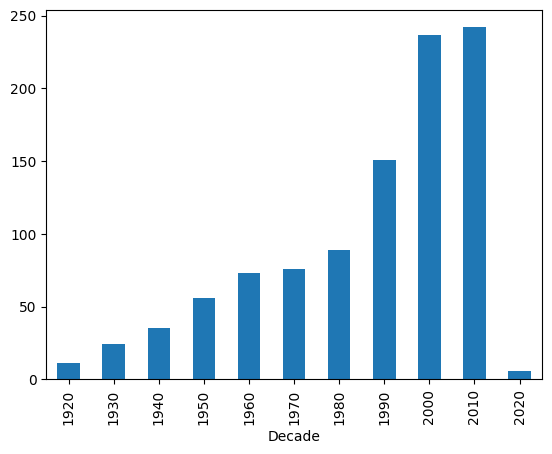

In [76]:
# Create a chart that shows how many movies fall in each decade.
imdb['Decade'].value_counts().sort_index().plot.bar()

<Axes: ylabel='proportion'>

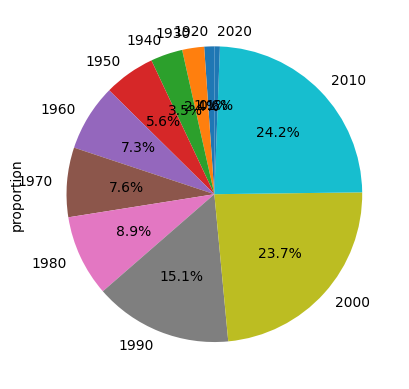

In [77]:
# Create a chart that shows the percentage of movies in each decade.
imdb['Decade'].value_counts(normalize=True).sort_index().plot(kind='pie', autopct='%1.1f%%', startangle=90)

<Axes: xlabel='count', ylabel='Director'>

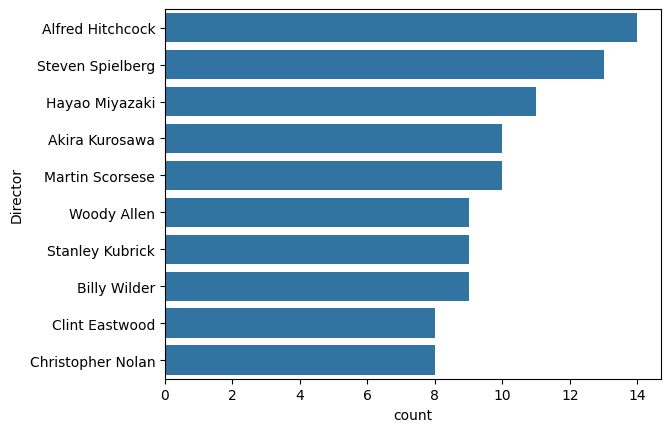

In [78]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
sns.countplot(data=imdb, y='Director', order=imdb['Director'].value_counts().iloc[:10].index)

<Axes: xlabel='IMDB_Rating', ylabel='Gross'>

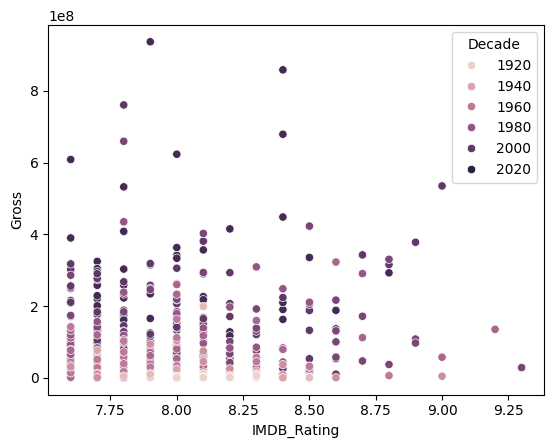

In [79]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
sns.scatterplot(data = imdb, x='IMDB_Rating', y='Gross', hue='Decade')
# Some of the higher grossing movies are from the 2020's

<Axes: ylabel='proportion'>

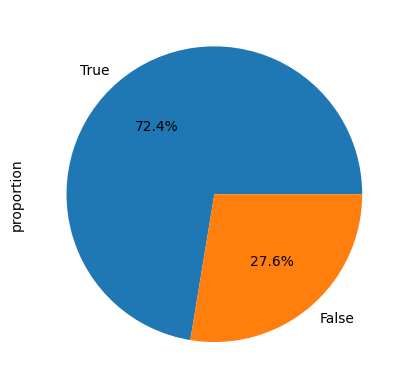

In [80]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
Drama = imdb['Genre'].str.contains('Drama')
imdb['Drama'] = Drama
imdb['Drama'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Decade', ylabel='Gross'>

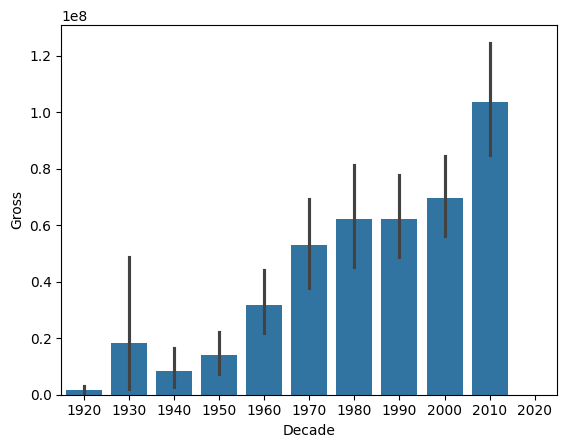

In [81]:
# Create a plot comparing gross revenue across decades.
sns.barplot(data=imdb, x='Decade', y='Gross')

<Axes: xlabel='Gross', ylabel='Count'>

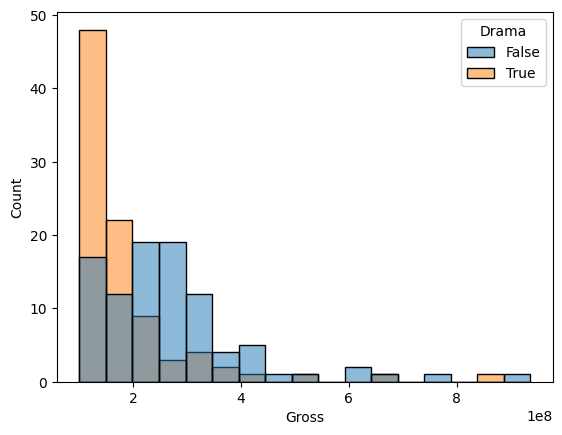

In [82]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.
sns.histplot(data=imdb[imdb['Gross'] > 100000000], x='Gross', hue='Drama')

<Axes: ylabel='proportion'>

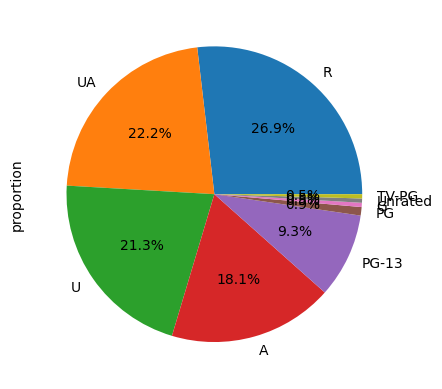

In [83]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: Pie chart showing percentage movies in 2000s belonging to different certificates
imdb[imdb['Decade'] == 2000]['Certificate'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')


<Axes: xlabel='Decade', ylabel='Gross'>

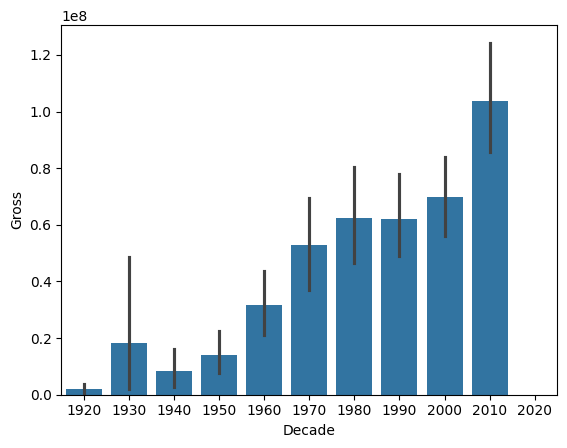

In [84]:
# Question 2: Barchart showing gross every decade
sns.barplot(data = imdb, x = 'Decade', y = 'Gross')
